# Two-dimensional Disk Distribution Functions

galpy includes several distribution functions (DFs) for razor-thin axisymmetric disks:
**dehnendf** ([Dehnen 1999](http://adsabs.harvard.edu/abs/1999AJ....118.1201D)), 
**shudf** ([Shu 1969](http://adsabs.harvard.edu/abs/1969ApJ...158..505S)), 
and **schwarzschilddf** (the Shu DF in the epicycle approximation, see [galaxiesbook.org](https://galaxiesbook.org/chapters/II-04.-Equilibria-of-Galactic-Disks_2-Distribution-functions-for-razor-thin-disks.html#the-first-and-simplest-example-of-a)).
These DFs are functions of energy and angular momentum, $f(E, L_z)$, and can be used to describe
stellar populations in a thin disk with a flat or power-law rotation curve.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.util.quadpack import AccuracyWarning
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=AccuracyWarning)

## Types of 2D disk DFs

All three DFs assume an exponential surface-density profile and an exponential
velocity-dispersion profile by default. They differ in how they construct $f(E, L_z)$
(see Section 10.2.2 in [galaxiesbook.org](https://galaxiesbook.org/chapters/II-04.-Equilibria-of-Galactic-Disks_2-Distribution-functions-for-razor-thin-disks.html#Distribution-functions-for-razor-thin-disks) for more details):

- **dehnendf**: Dehnen's 'new' DF (Dehnen 1999)
- **shudf**: Shu's DF (Shu 1969)
- **schwarzschilddf**: Schwarzschild DF

All operate in a potential with a power-law rotation curve $v_c \propto R^\beta$.

## Initializing a Dehnen DF

We initialize a `dehnendf` with a flat rotation curve (`beta=0.`). The default
`profileParams=(1/3, 1, 0.2)` set the disk scale length, velocity-dispersion
scale length, and velocity dispersion at $R_0$ (all in natural units).

In [2]:
from galpy.df import dehnendf

dfc = dehnendf(beta=0.0)

The `profileParams` tuple is `(xD, xS, Sro)` where:
- `xD = 1/3`: disk surface mass scale length (in units of $R_0$)
- `xS = 1.0`: velocity dispersion scale length
- `Sro = 0.2`: velocity dispersion at $R_0$ (in units of $v_c(R_0)$)

We can also use custom profile parameters:

In [3]:
dfc2 = dehnendf(beta=0.0, profileParams=(1.0 / 3.0, 1.0, 0.15))

## Evaluating the DF for an orbit

The DF can be evaluated for a given orbit (a point in phase space).
We create an `Orbit` object and pass it to the DF:

In [4]:
from galpy.orbit import Orbit

# An orbit at R=0.9, vR=0.05, vT=1.0
o = Orbit([0.9, 0.05, 1.0])
print("f(orbit) =", dfc(o))

f(orbit) = 0.3014411904461411


## DF moments: surface mass, velocity dispersions, and mean velocities

We can compute various moments of the DF by marginalizing over velocity.
These are useful for comparing the DF to observations.

In [5]:
# Surface mass density at R=1
print("Surface mass at R=1.0:", dfc.surfacemass(1.0))

# Radial velocity dispersion squared
print("sigma_R^2 at R=1.0:", dfc.sigma2(1.0))

# Mean tangential velocity
print("<v_T> at R=1.0:", dfc.meanvT(1.0))

# Mean radial velocity (should be ~0 for an axisymmetric DF)
print("<v_R> at R=1.0:", dfc.meanvR(1.0))

Surface mass at R=1.0: 0.050968080499022066


sigma_R^2 at R=1.0: 0.03733043742309621


<v_T> at R=1.0: 0.9171527697944728
<v_R> at R=1.0: 0.0


Let's plot the surface mass profile and compare it to the target exponential profile:

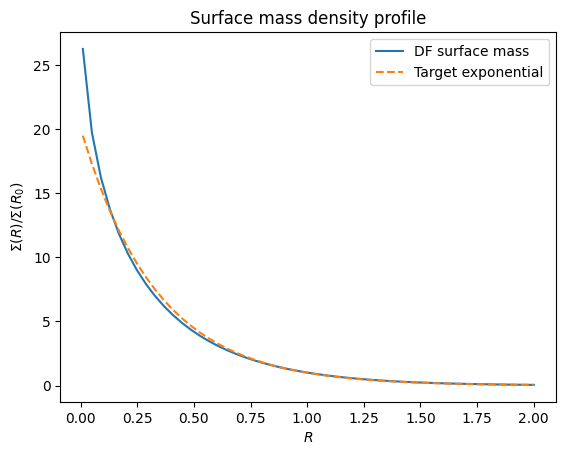

In [6]:
Rs = numpy.linspace(0.01, 2.0, 51)
smass = numpy.array([dfc.surfacemass(R) for R in Rs])
plt.plot(Rs, smass / smass[25], label="DF surface mass")
plt.plot(Rs, numpy.exp(-(Rs - 1.0) / (1.0 / 3.0)), "--", label="Target exponential")
plt.xlabel(r"$R$")
plt.ylabel(r"$\Sigma(R) / \Sigma(R_0)$")
plt.legend()
plt.title("Surface mass density profile");

## Asymmetric drift

The asymmetric drift is the difference between the circular velocity and
the mean tangential velocity: $v_c - \langle v_T \rangle$. The DF can 
calculate this directly as $v_c - \langle v_T \rangle$ or we can also
estimate this from an approximation to the Jeans equation using ``asymmetricdrift`` (see [galaxiesbook.org](https://galaxiesbook.org/chapters/II-04.-Equilibria-of-Galactic-Disks_1-The-axisymmetric-Jeans-equations-and-the-asymmetric-drift.html#The-asymmetric-drift) for more details):

Estimated asymmetric drift at R=1.0: 0.09000000000000002


 vs. correct one from mean tangential velocity: 0.0828472302055272


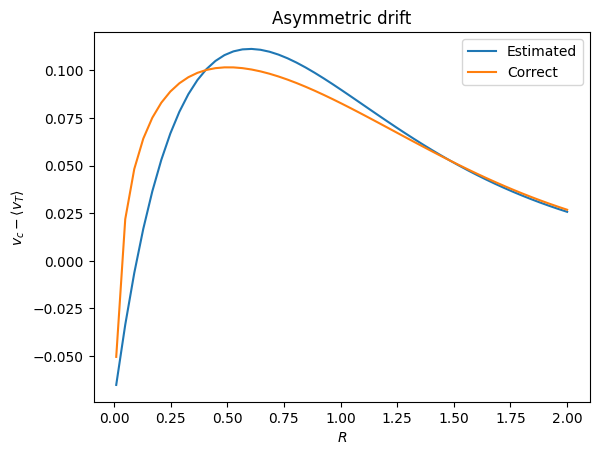

In [7]:
print(f"Estimated asymmetric drift at R=1.0: {dfc.asymmetricdrift(1.0)}")
print(f" vs. correct one from mean tangential velocity: {1.0 - dfc.meanvT(1.0)}")

# Plot asymmetric drift as a function of R
ad = numpy.array([dfc.asymmetricdrift(R) for R in Rs])
ad_correct = numpy.array([1.0 - dfc.meanvT(R) for R in Rs])
plt.plot(Rs, ad, label="Estimated")
plt.plot(Rs, ad_correct, label="Correct")
plt.xlabel(r"$R$")
plt.ylabel(r"$v_c - \langle v_T \rangle$")
plt.title("Asymmetric drift")
plt.legend();

## Sampling orbits from the DF

We can draw random samples from the DF. The `sample` method returns `Orbit` objects:

In [8]:
samples = dfc.sample(n=500, returnOrbit=True, nphi=1)
print("Number of sampled orbits:", len(samples))
print("First orbit R, vR, vT:", samples[0].R(), samples[0].vR(), samples[0].vT())

Number of sampled orbits: 500
First orbit R, vR, vT: 0.6604630188577291 0.36587312788109305 0.7849238755890448


## Plotting the velocity distribution

We can sample velocities at a specific radius and plot their distribution.
The `sampleVRVT` method samples $(v_R, v_T)$ at a given $R$:

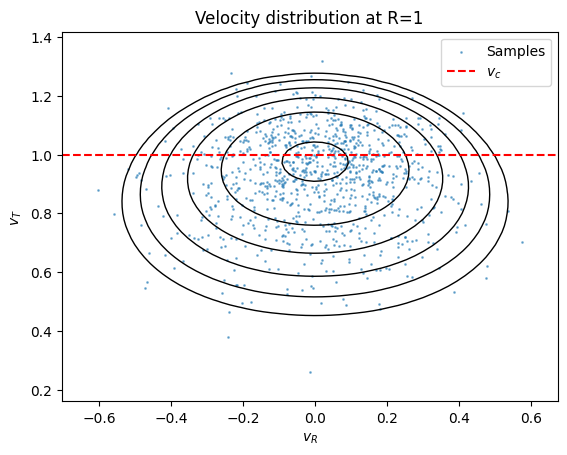

In [9]:
vrvt = dfc.sampleVRVT(1.0, n=1000)
plt.scatter(vrvt[:, 0], vrvt[:, 1], s=1, alpha=0.5, label="Samples")

# Evaluate DF on a (vR, vT) grid at R=1 and overplot contours
vR_grid = numpy.linspace(vrvt[:, 0].min() - 0.1, vrvt[:, 0].max() + 0.1, 60)
vT_grid = numpy.linspace(vrvt[:, 1].min() - 0.1, vrvt[:, 1].max() + 0.1, 60)
vR2d, vT2d = numpy.meshgrid(vR_grid, vT_grid)

df_grid = numpy.array([[dfc(Orbit([1.0, vR, vT])) for vR in vR_grid] for vT in vT_grid])

levels = numpy.geomspace(0.02 * df_grid.max(), 0.9 * df_grid.max(), 6)
plt.contour(vR2d, vT2d, df_grid, levels=levels, colors="k", linewidths=1.0)

plt.xlabel(r"$v_R$")
plt.ylabel(r"$v_T$")
plt.title("Velocity distribution at R=1")
plt.axhline(1.0, color="r", ls="--", label=r"$v_c$")
plt.legend();

The distribution is centered slightly below $v_c = 1$ due to the asymmetric drift,
and has a spread set by the velocity dispersion.

## Other 2D DFs

The `shudf` and `schwarzschilddf` classes have the same interface:

In [10]:
from galpy.df import shudf, schwarzschilddf

dfs = shudf(beta=0.0)
dfsw = schwarzschilddf(beta=0.0)

print("Shu DF surface mass at R=1:", dfs.surfacemass(1.0))
print("Schwarzschild DF surface mass at R=1:", dfsw.surfacemass(1.0))

Shu DF surface mass at R=1: 0.062193623796354555
Schwarzschild DF surface mass at R=1: 0.0689371283692479


## Corrected DFs

The input profiles are only approximately reproduced by the DF. We can correct
this by calculating a set of corrections (see Dehnen 1999). galpy supports
these corrections and comes with pre-calculated corrections bundled with the code:

sigma_R (corrected vs. uncorrected): 0.1999998506941359 0.19321086259083936


meanvT (corrected vs. uncorrected): 0.9035516117477274 0.9171527697944728


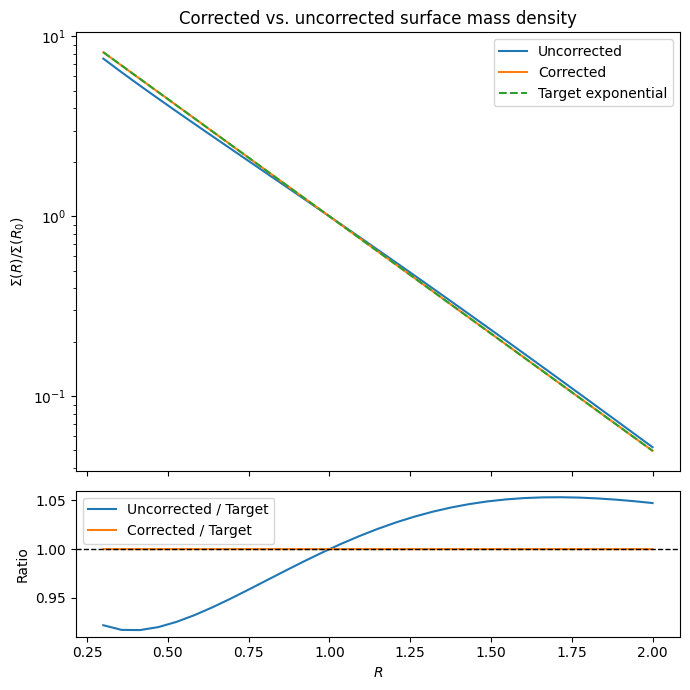

In [11]:
dfc_corr = dehnendf(beta=0.0, correct=True)

# The corrected DF reproduces the target velocity dispersion much better
print(
    "sigma_R (corrected vs. uncorrected):",
    numpy.sqrt(dfc_corr.sigmaR2(1.0)),
    numpy.sqrt(dfc.sigmaR2(1.0)),
)
print("meanvT (corrected vs. uncorrected):", dfc_corr.meanvT(1.0), dfc.meanvT(1.0))

# Compare surface mass profiles and ratios to target
Rs = numpy.linspace(0.3, 2.0, 31)
smass_uncorr = numpy.array([dfc.surfacemass(R) for R in Rs]) / dfc.surfacemass(1.0)
smass_corr = numpy.array([dfc_corr.surfacemass(R) for R in Rs]) / dfc_corr.surfacemass(
    1.0
)
target = numpy.exp(-(Rs - 1.0) / (1.0 / 3.0))

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(7, 7), gridspec_kw={"height_ratios": [3, 1]}
)

# Top panel: profiles
ax1.semilogy(Rs, smass_uncorr, label="Uncorrected")
ax1.semilogy(Rs, smass_corr, label="Corrected")
ax1.semilogy(Rs, target, "--", label="Target exponential")
ax1.set_ylabel(r"$\Sigma(R) / \Sigma(R_0)$")
ax1.set_title("Corrected vs. uncorrected surface mass density")
ax1.legend()

# Bottom panel: ratio to target
ax2.plot(Rs, smass_uncorr / target, label="Uncorrected / Target")
ax2.plot(Rs, smass_corr / target, label="Corrected / Target")
ax2.axhline(1.0, color="k", ls="--", lw=1)
ax2.set_xlabel(r"$R$")
ax2.set_ylabel("Ratio")
ax2.legend()

plt.tight_layout()

galpy will automatically save any new corrections that you calculate.

## Oort constants

galpy can calculate the Oort constants (A, B, C, K) for 2D disk DFs by direct
integration over the DF and its derivatives:

In [12]:
print("Oort A:", dfc.oortA(1.0))
print("Oort B:", dfc.oortB(1.0))
print("Oort C:", dfc.oortC(1.0))  # zero for axisymmetric DFs
print("Oort K:", dfc.oortK(1.0))  # zero for axisymmetric DFs
# In the epicycle approximation for a flat rotation curve, A = -B = 0.5
print(
    "A + B (should be ~0 for cold DF w/ flat rotation curve):",
    dfc.oortA(1.0) + dfc.oortB(1.0),
)

# For a cold DF, the epicycle approximation is better:
dfccold = dehnendf(beta=0.0, profileParams=(1.0 / 3.0, 1.0, 0.02))
print("Cold DF: A =", dfccold.oortA(1.0), ", B =", dfccold.oortB(1.0))

Oort A: 0.4319078088921877


Oort B: -0.4852449609022851


Oort C: 0.0


Oort K: 0.0


A + B (should be ~0 for cold DF w/ flat rotation curve): -0.053337152010097366


Cold DF: A = 0.4991755666614268 , B = -0.4999282474249216


## Line-of-sight sampling

galpy supports sampling along a given line of sight in the disk, useful for
interpreting surveys with a finite number of pointings:

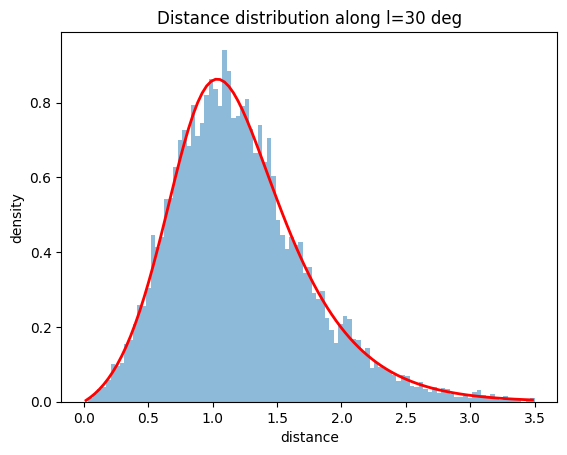

In [13]:
# Sample distances along a line of sight at l=30 degrees
ds = dfc.sampledSurfacemassLOS(30.0 / 180.0 * numpy.pi, n=10000)
hists, bins, edges = plt.hist(ds, range=[0.0, 3.5], density=True, bins=101, alpha=0.5)
# Compare to the predicted distribution
xs = numpy.array([(bins[ii + 1] + bins[ii]) / 2.0 for ii in range(len(bins) - 1)])
fd = numpy.array([dfc.surfacemassLOS(d, 30.0) for d in xs])
plt.plot(xs, fd / numpy.sum(fd) / (xs[1] - xs[0]), "r-", lw=2)
plt.xlabel("distance")
plt.ylabel("density")
plt.title("Distance distribution along l=30 deg");

## Non-axisymmetric, time-dependent DFs: evolveddiskdf

galpy supports evaluation of non-axisymmetric, time-dependent 2D DFs.
These are constructed by assuming an initial axisymmetric steady state
that is then acted upon by a non-axisymmetric perturbation. The DF at any
time is evaluated by integrating orbits backwards to the initial time
(using Liouville's theorem). This is implemented as `galpy.df.evolveddiskdf`.

In [14]:
from galpy.potential import LogarithmicHaloPotential, EllipticalDiskPotential
from galpy.df import evolveddiskdf

# Set up an elliptical perturbation to a logarithmic potential
lp = LogarithmicHaloPotential(normalize=1.0)
ep = EllipticalDiskPotential(twophio=0.05, phib=0.0, p=0.0, tform=-150.0, tsteady=125.0)

# Initial steady-state DF (warm disk)
idfwarm = dehnendf(beta=0.0, profileParams=(1.0 / 3.0, 1.0, 0.15))

# Set up the evolved DF
edfwarm = evolveddiskdf(idfwarm, lp + ep, to=-150.0)

# Mean radial velocity at R=0.9, phi=22.5 deg
mvrwarm, gridwarm = edfwarm.meanvR(
    0.9, phi=22.5, deg=True, t=0.0, grid=True, returnGrid=True, gridpoints=51
)
print("Mean v_R (warm disk):", mvrwarm)

Mean v_R (warm disk): -0.029476364282585484


## Example: The Hercules stream

We can combine galpy's orbit integration capabilities with the
disk distribution functions to see the effect of the Galactic bar
on stellar velocities. By backward-integrating orbits starting at the
Solar position in a potential that includes the bar, we can
see what the velocity distribution should look like today if
the Galactic bar stirred up a steady-state disk (see [Dehnen 2000](http://adsabs.harvard.edu/abs/2000AJ....119..800D) and [Bovy 2010](http://adsabs.harvard.edu/abs/2010ApJ...725.1676B)).

In [15]:
from galpy.potential import LogarithmicHaloPotential, DehnenBarPotential
from galpy.df import dehnendf

lp = LogarithmicHaloPotential(normalize=1.0)
dp = DehnenBarPotential()

# Integrate back to before bar formation
ts = numpy.linspace(0, dp.tform(), 1000)

# Grid in velocity space at the Solar position
ins = Orbit(
    numpy.array(
        [
            [
                [1.0, -0.7 + 1.4 / 100 * jj, 1.0 - 0.6 + 1.2 / 100 * ii, 0.0]
                for jj in range(101)
            ]
            for ii in range(101)
        ]
    )
)
ins.integrate(ts, lp + dp)

Evaluate the weight of each orbit using a Dehnen DF at the time of bar formation:

In [16]:
dfc = dehnendf(beta=0.0, correct=True)
out = [[dfc(o(dp.tform())) for o in j] for j in ins]
out = numpy.array(out)

Plot the velocity distribution:

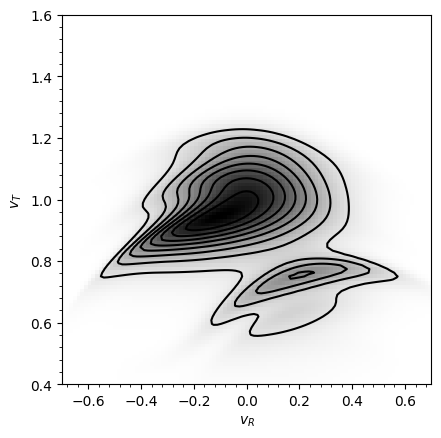

In [17]:
from galpy.util.plot import dens2d

dens2d(
    out,
    origin="lower",
    cmap="gist_yarg",
    contours=True,
    xrange=[-0.7, 0.7],
    yrange=[0.4, 1.6],
    xlabel=r"$v_R$",
    ylabel=r"$v_T$",
);

This entire calculation is encapsulated in the `evolveddiskdf` module:

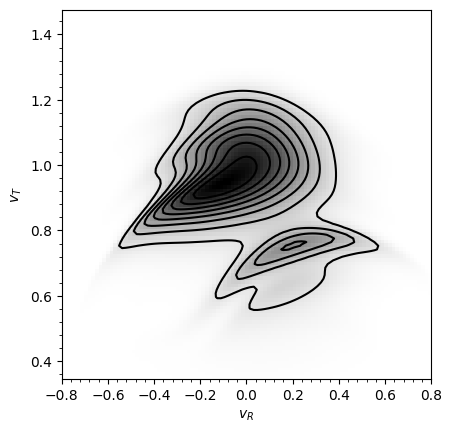

In [18]:
from galpy.df import evolveddiskdf

edf = evolveddiskdf(dfc, lp + dp, to=dp.tform())
mvr, grid = edf.meanvR(1.0, grid=True, gridpoints=101, returnGrid=True)
dens2d(
    grid.df.T,
    origin="lower",
    cmap="gist_yarg",
    contours=True,
    xrange=[grid.vRgrid[0], grid.vRgrid[-1]],
    yrange=[grid.vTgrid[0], grid.vTgrid[-1]],
    xlabel=r"$v_R$",
    ylabel=r"$v_T$",
);

The Hercules stream is the feature at $(v_R, v_T) \approx (-0.3, 0.8)$. Note that the $v_R$ axis here is defined as the negative of the convention in [Dehnen (2000)](http://adsabs.harvard.edu/abs/2000AJ....119..800D) and [Bovy (2010)](http://adsabs.harvard.edu/abs/2010ApJ...725.1676B).